In [3]:
# Import necessary libraries
import optuna
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Pima Indian Diabetes dataset from sklearn
# Note: Scikit-learn's built-in 'load_diabetes' is a regression dataset.
# We will load the actual diabetes dataset from an external source
import pandas as pd

# Load the Pima Indian Diabetes dataset (from UCI repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the dataset
df = pd.read_csv(url, names=columns)

df.head()

C:\Users\Nandika\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
import numpy as np

# Replace zero values with NaN in columns where zero is not a valid value
cols_with_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing_vals] = df[cols_with_missing_vals].replace(0, np.nan)

# Impute the missing values with the mean of the respective column
df.fillna(df.mean(), inplace=True)

# Check if there are any remaining missing values
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
# Split into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check the shape of the data
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')


Training set shape: (537, 8)
Test set shape: (231, 8)


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [7]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters


[I 2026-08-11 23:37:06,179] A new study created in memory with name: no-name-d6368b80-da86-43f7-98ad-edc9b5ea00a4
[I 2026-08-11 23:37:06,810] Trial 0 finished with value: 0.7616387337057727 and parameters: {'n_estimators': 93, 'max_depth': 11}. Best is trial 0 with value: 0.7616387337057727.
[I 2026-08-11 23:37:07,144] Trial 1 finished with value: 0.7597765363128492 and parameters: {'n_estimators': 55, 'max_depth': 12}. Best is trial 0 with value: 0.7616387337057727.
[I 2026-08-11 23:37:08,064] Trial 2 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 152, 'max_depth': 15}. Best is trial 2 with value: 0.7709497206703911.
[I 2026-08-11 23:37:08,711] Trial 3 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 114, 'max_depth': 14}. Best is trial 2 with value: 0.7709497206703911.
[I 2026-08-11 23:37:09,732] Trial 4 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 187, 'max_depth': 14}. Best is trial 2 with value: 0.770949

In [8]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7821229050279329
Best hyperparameters: {'n_estimators': 107, 'max_depth': 15}


In [9]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.76


## Samplers in Optuna

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [12]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

[I 2026-08-11 23:37:44,759] A new study created in memory with name: no-name-37461626-0aba-4e4b-a0fa-74260d66cf78
[I 2026-08-11 23:37:45,618] Trial 0 finished with value: 0.7635009310986964 and parameters: {'n_estimators': 110, 'max_depth': 4}. Best is trial 0 with value: 0.7635009310986964.
[I 2026-08-11 23:37:45,956] Trial 1 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 58, 'max_depth': 14}. Best is trial 1 with value: 0.7653631284916201.
[I 2026-08-11 23:37:47,243] Trial 2 finished with value: 0.7635009310986964 and parameters: {'n_estimators': 199, 'max_depth': 9}. Best is trial 1 with value: 0.7653631284916201.
[I 2026-08-11 23:37:48,458] Trial 3 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 187, 'max_depth': 12}. Best is trial 3 with value: 0.7709497206703911.
[I 2026-08-11 23:37:49,400] Trial 4 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 164, 'max_depth': 5}. Best is trial 3 with value: 0.77094972

In [13]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7783985102420856
Best hyperparameters: {'n_estimators': 118, 'max_depth': 19}


In [14]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.74


In [15]:
search_space = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20]
}

In [16]:
# Create a study and optimize it using GridSampler
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.GridSampler(search_space))
study.optimize(objective)

[I 2026-08-11 23:38:22,377] A new study created in memory with name: no-name-6c86e819-7fe3-4ad7-ac21-55bf6c44d532
[I 2026-08-11 23:38:23,091] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 5}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-08-11 23:38:24,104] Trial 1 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 150, 'max_depth': 10}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-08-11 23:38:24,399] Trial 2 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 50, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2026-08-11 23:38:25,122] Trial 3 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 100, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2026-08-11 23:38:25,848] Trial 4 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 20}. Best is trial 2 with value: 0.772811

In [17]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7746741154562384
Best hyperparameters: {'n_estimators': 50, 'max_depth': 5}


In [18]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.74


## Optuna Visualizations

In [20]:
# For visualizations
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

In [21]:
# 1. Optimization History
plot_optimization_history(study).show()

In [22]:
# 2. Parallel Coordinates Plot
plot_parallel_coordinate(study).show()

In [23]:
# 3. Slice Plot
plot_slice(study).show()

In [24]:
# 4. Contour Plot
plot_contour(study).show()

In [25]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

## Optimizing Multiple ML Models

In [27]:
# Importing the required libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [28]:
# Define the objective function for Optuna
def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical('classifier', ['SVM', 'RandomForest', 'GradientBoosting'])

    if classifier_name == 'SVM':
        # SVM hyperparameters
        c = trial.suggest_float('C', 0.1, 100, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

        model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)

    elif classifier_name == 'RandomForest':
        # Random Forest hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    elif classifier_name == 'GradientBoosting':
        # Gradient Boosting hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

In [29]:
# Create a study and optimize it using CmaEsSampler
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-08-11 23:38:36,433] A new study created in memory with name: no-name-441a115a-0e80-4900-a0c7-cfcdd3240c2f
[I 2026-08-11 23:38:36,477] Trial 0 finished with value: 0.702048417132216 and parameters: {'classifier': 'SVM', 'C': 18.039512132837086, 'kernel': 'sigmoid', 'gamma': 'scale'}. Best is trial 0 with value: 0.702048417132216.
[I 2026-08-11 23:38:38,790] Trial 1 finished with value: 0.74487895716946 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 147, 'learning_rate': 0.20971332738008638, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.74487895716946.
[I 2026-08-11 23:38:39,318] Trial 2 finished with value: 0.7318435754189944 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 79, 'learning_rate': 0.2352687177987, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.74487895716946.
[I 2026-08-11 23:38:41,120] Trial 3 finished with value: 0.759776536312849

In [30]:
# Retrieve the best trial
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'classifier': 'SVM', 'C': 0.1373205563672853, 'kernel': 'linear', 'gamma': 'auto'}
Best trial accuracy: 0.7895716945996275


In [31]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_C,params_bootstrap,params_classifier,params_gamma,params_kernel,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
0,0,0.702048,2026-08-11 23:38:36.434902,2026-08-11 23:38:36.476754,0 days 00:00:00.041852,18.039512,NaN,SVM,scale,sigmoid,NaN,NaN,NaN,NaN,NaN,COMPLETE
1,1,0.744879,2026-08-11 23:38:36.477762,2026-08-11 23:38:38.790049,0 days 00:00:02.312287,NaN,NaN,GradientBoosting,NaN,NaN,0.209713,19.0,4.0,4.0,147.0,COMPLETE
2,2,0.731844,2026-08-11 23:38:38.791217,2026-08-11 23:38:39.318565,0 days 00:00:00.527348,NaN,NaN,GradientBoosting,NaN,NaN,0.235269,6.0,5.0,10.0,79.0,COMPLETE
3,3,0.759777,2026-08-11 23:38:39.319863,2026-08-11 23:38:41.120599,0 days 00:00:01.800736,NaN,True,RandomForest,NaN,NaN,NaN,6.0,4.0,5.0,290.0,COMPLETE
4,4,0.757914,2026-08-11 23:38:41.121850,2026-08-11 23:38:42.438594,0 days 00:00:01.316744,NaN,True,RandomForest,NaN,NaN,NaN,8.0,7.0,2.0,206.0,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.743017,2026-08-11 23:39:12.850707,2026-08-11 23:39:12.909758,0 days 00:00:00.059051,0.117897,NaN,SVM,scale,rbf,NaN,NaN,NaN,NaN,NaN,COMPLETE
96,96,0.785847,2026-08-11 23:39:12.911772,2026-08-11 23:39:12.947393,0 days 00:00:00.035621,0.242211,NaN,SVM,auto,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
97,97,0.724395,2026-08-11 23:39:12.948391,2026-08-11 23:39:14.309125,0 days 00:00:01.360734,NaN,NaN,GradientBoosting,NaN,NaN,0.131161,17.0,2.0,6.0,74.0,COMPLETE
98,98,0.787709,2026-08-11 23:39:14.309125,2026-08-11 23:39:14.351884,0 days 00:00:00.042759,0.155214,NaN,SVM,auto,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE


In [32]:
study.trials_dataframe()['params_classifier'].value_counts()

params_classifier
SVM                 77
GradientBoosting    12
RandomForest        11
Name: count, dtype: int64

In [33]:
study.trials_dataframe().groupby('params_classifier')['value'].mean()

params_classifier
GradientBoosting    0.734482
RandomForest        0.761300
SVM                 0.777431
Name: value, dtype: float64

In [34]:
# 1. Optimization History
plot_optimization_history(study).show()

In [35]:
# 3. Slice Plot
plot_slice(study).show()

In [36]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

In [41]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import numpy as np

# Load the Iris dataset
X, y = load_iris(return_X_y=True)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the objective function for XGBoost
def objective(trial):
    # Hyperparameter search space
    param = {
        'verbosity': 0,
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',  # Ensure that the eval_metric is specified here
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'n_estimators': 300,
    }

    # Create DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # Define a pruning callback based on evaluation metrics
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "eval-mlogloss")  # Match the metric name in the evals list

    # Train the model
    bst = xgb.train(
        param,
        dtrain,
        num_boost_round=300,
        evals=[(dtrain, "train"), (dtest, "eval")],  # Ensure the eval datasets and names are specified
        early_stopping_rounds=30,
        callbacks=[pruning_callback]
    )

    # Predict on the test set
    preds = bst.predict(dtest)
    best_preds = [int(np.argmax(line)) for line in preds]

    # Return accuracy as the objective value
    accuracy = accuracy_score(y_test, best_preds)
    return accuracy

# Create a study with pruning
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.SuccessiveHalvingPruner())
study.optimize(objective, n_trials=50)

# Output the best trial
print(f"Best trial: {study.best_trial.params}")
print(f"Best accuracy: {study.best_value}")


[I 2026-08-11 23:39:59,780] A new study created in memory with name: no-name-cb4524e3-56d0-49df-8b8f-35e712491f7d


[0]	train-mlogloss:0.82123	eval-mlogloss:0.81573
[1]	train-mlogloss:0.63122	eval-mlogloss:0.61936
[2]	train-mlogloss:0.50137	eval-mlogloss:0.48237
[3]	train-mlogloss:0.40757	eval-mlogloss:0.37226
[4]	train-mlogloss:0.33562	eval-mlogloss:0.29414
[5]	train-mlogloss:0.27965	eval-mlogloss:0.23152
[6]	train-mlogloss:0.24409	eval-mlogloss:0.18922
[7]	train-mlogloss:0.21733	eval-mlogloss:0.16213
[8]	train-mlogloss:0.19483	eval-mlogloss:0.13782
[9]	train-mlogloss:0.17983	eval-mlogloss:0.12196
[10]	train-mlogloss:0.17663	eval-mlogloss:0.11837
[11]	train-mlogloss:0.17368	eval-mlogloss:0.11672
[12]	train-mlogloss:0.15986	eval-mlogloss:0.10047


C:\Users\Nandika\anaconda3\Lib\importlib\__init__.py:90: FutureWarning: `optuna.integration.xgboost` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.xgboost` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


[13]	train-mlogloss:0.15576	eval-mlogloss:0.09509
[14]	train-mlogloss:0.15156	eval-mlogloss:0.08766
[15]	train-mlogloss:0.15018	eval-mlogloss:0.08721
[16]	train-mlogloss:0.14505	eval-mlogloss:0.07983
[17]	train-mlogloss:0.14491	eval-mlogloss:0.07820
[18]	train-mlogloss:0.14376	eval-mlogloss:0.07535
[19]	train-mlogloss:0.14380	eval-mlogloss:0.07530
[20]	train-mlogloss:0.13939	eval-mlogloss:0.07103
[21]	train-mlogloss:0.13845	eval-mlogloss:0.06914
[22]	train-mlogloss:0.13801	eval-mlogloss:0.06892
[23]	train-mlogloss:0.13798	eval-mlogloss:0.06844
[24]	train-mlogloss:0.13655	eval-mlogloss:0.06376
[25]	train-mlogloss:0.13670	eval-mlogloss:0.06351
[26]	train-mlogloss:0.13652	eval-mlogloss:0.06336
[27]	train-mlogloss:0.13632	eval-mlogloss:0.06460
[28]	train-mlogloss:0.13525	eval-mlogloss:0.06753
[29]	train-mlogloss:0.13464	eval-mlogloss:0.06757
[30]	train-mlogloss:0.13484	eval-mlogloss:0.06897
[31]	train-mlogloss:0.13362	eval-mlogloss:0.06866
[32]	train-mlogloss:0.13385	eval-mlogloss:0.07041


[I 2026-08-11 23:40:01,395] Trial 0 finished with value: 1.0 and parameters: {'lambda': 0.6289611045053325, 'alpha': 1.8837666452001475e-07, 'eta': 0.26417046509179654, 'gamma': 0.0035523999971676856, 'max_depth': 8, 'min_child_weight': 3, 'subsample': 0.4590764977591292, 'colsample_bytree': 0.7818820473568686}. Best is trial 0 with value: 1.0.


...

[0]	train-mlogloss:0.97710	eval-mlogloss:0.96888


[I 2026-08-11 23:40:21,034] Trial 48 pruned. Trial was pruned at iteration 1.


[0]	train-mlogloss:0.77040	eval-mlogloss:0.74980


[I 2026-08-11 23:40:21,093] Trial 49 pruned. Trial was pruned at iteration 1.


Best trial: {'lambda': 0.6289611045053325, 'alpha': 1.8837666452001475e-07, 'eta': 0.26417046509179654, 'gamma': 0.0035523999971676856, 'max_depth': 8, 'min_child_weight': 3, 'subsample': 0.4590764977591292, 'colsample_bytree': 0.7818820473568686}
Best accuracy: 1.0


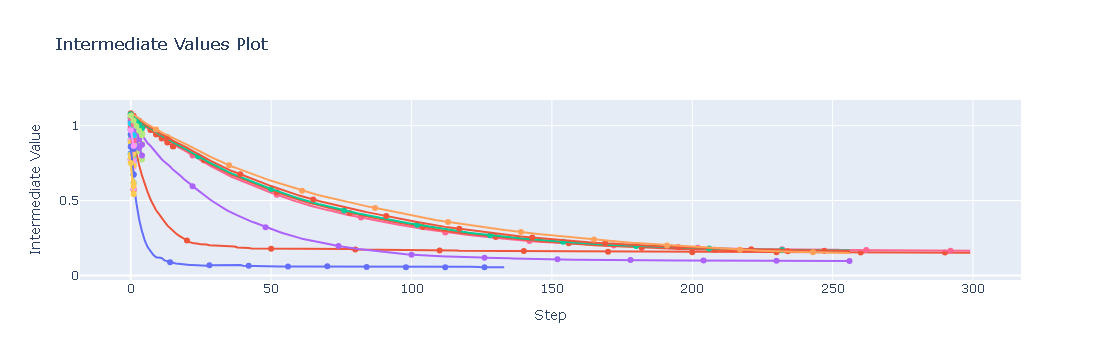

In [43]:
from optuna.visualization import plot_intermediate_values

# 1. Plot intermediate values during the trials
plot_intermediate_values(study).show()